<a href="https://colab.research.google.com/github/bhanusri195/MLA0204/blob/main/experiment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import math

# Define a class for the decision tree node
class DecisionTreeNode:
    def __init__(self, attribute=None, label=None, branches=None):
        self.attribute = attribute  # the attribute used to split the data
        self.label = label  # the label assigned to this node
        self.branches = branches if branches is not None else {}  # the branches of the decision tree

# Define a function to calculate the entropy of a dataset
def entropy(data):
    target = data['Target']
    n = len(target)
    unique, counts = np.unique(target, return_counts=True)
    entropy_val = 0
    for i in range(len(unique)):
        p = counts[i] / n
        entropy_val -= p * math.log2(p)
    return entropy_val

# Define a function to calculate the information gain of an attribute
def information_gain(data, attribute):
    n = len(data)
    values = data[attribute].unique()
    entropy_s = entropy(data)
    entropy_attr = 0
    for value in values:
        subset = data[data[attribute] == value]
        subset_n = len(subset)
        subset_entropy = entropy(subset)
        entropy_attr += subset_n / n * subset_entropy
    return entropy_s - entropy_attr

# Define the ID3 algorithm
def id3(data, attributes):
    target = data['Target']
    # If all the examples have the same target value, return a leaf node with that value
    if len(target.unique()) == 1:
        return DecisionTreeNode(label=target.iloc[0])
    # If there are no attributes left to split on, return a leaf node with the most common target value
    if len(attributes) == 0:
        return DecisionTreeNode(label=target.value_counts().idxmax())
    # Otherwise, select the attribute with the highest information gain
    gains = {attr: information_gain(data, attr) for attr in attributes}
    best_attribute = max(gains, key=gains.get)
    # Create a new decision tree node with the selected attribute
    node = DecisionTreeNode(attribute=best_attribute)
    # Split the data based on the selected attribute and recursively build the tree
    for value in data[best_attribute].unique():
        subset = data[data[best_attribute] == value].drop(best_attribute, axis=1)
        if len(subset) == 0:
            node.branches[value] = DecisionTreeNode(label=target.value_counts().idxmax())
        else:
            new_attributes = attributes.copy()
            if best_attribute in new_attributes:
                new_attributes.remove(best_attribute)
            node.branches[value] = id3(subset, new_attributes)
    return node

# Load the dataset
data = pd.read_csv('play_tennis.csv')
# Split the dataset into attributes and target variable
attributes = data.columns[:-1].tolist()
# Build the decision tree using ID3 algorithm
root = id3(data, attributes)

# Define a function to classify a new sample using the decision tree
def classify(sample, tree):
    if tree.label is not None:
        return tree.label
    attribute = tree.attribute
    value = sample[attribute]
    if value not in tree.branches:
        # Fallback to the first available branch if value is not matched
        return tree.branches[list(tree.branches.keys())[0]].label
    return classify(sample, tree.branches[value])

# Test with a sample from the data
test_sample = data.iloc[0]
prediction = classify(test_sample, root)
print(f"Prediction for first sample: {prediction} (Actual: {test_sample['Target']})")

Prediction for first sample: no (Actual: no)


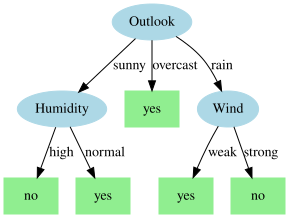

In [11]:
import graphviz

def build_graphviz_tree(node, dot=None, parent_id=None, edge_label=None):
    if dot is None:
        dot = graphviz.Digraph(comment='Decision Tree')

    current_id = str(id(node))

    if node.label is not None:
        # It's a leaf node
        dot.node(current_id, label=f"{node.label}", shape='box', style='filled', color='lightgreen')
    else:
        # It's an internal split node
        dot.node(current_id, label=f"{node.attribute}", shape='ellipse', style='filled', color='lightblue')

    if parent_id is not None:
        dot.edge(parent_id, current_id, label=edge_label)

    if node.branches:
        for value, branch in node.branches.items():
            build_graphviz_tree(branch, dot, current_id, str(value))

    return dot

# Generate and render the tree graph
tree_graph = build_graphviz_tree(root)
display(tree_graph)